# Compare Explanation Families

Stage 2 asks whether automated simulatability distinguishes explanation families from no-explanation baselines under the harmonized one-sample-per-prompt setup.

The previous working notebook was archived to `notebooks/old/5_compare_families.ipynb` for reference.

What this notebook does:

1. Load one judge's v2 score CSV.
2. Infer each row's explanation family.
3. Canonicalize duplicated baseline rows by taking their mean.
4. Summarize score distributions with the same 10-seed bucket convention used elsewhere.
5. Select the best non-baseline method/configuration per family.
6. Plot best family configs against baselines, separated by `(dataset, classes_subset)`.
7. Build a best-method allow-list for the future `data/best_prompts/` subset.

Reusable visualization code lives in `utils/plot.py`. This notebook keeps data filtering and selection logic explicit for traceability.


## 1. Parameters

Change these values to control the scope. Defaults target the Qwen3.5-9B Stage 2 comparison.


In [1]:
MODEL_FILE = "Qwen_Qwen3.5-9B"

# Stage 2 currently compares the harmonized current ConSim concept prompts
# with rationale and attribution prompts. If Stage 1 selects simulator_consim,
# change this list after regenerating and rescoring the corresponding prompts.
SPECIFICATIONS = ["new_consim", "rationales", "attributions"]

# Optional filters. None means keep everything present in the score file.
DATASETS = None             # e.g. ["RT", "AG"]
CLASSES_SUBSETS = None      # e.g. ["[0, 1]"]
FAMILIES = None             # e.g. ["concepts", "rationales", "attributions"]
PROMPT_TYPES = None         # e.g. ["B1", "B2", "C1", "R1", "A1"]
METHODS = None              # e.g. ["SemiNMF", "saliency"]

# Use non-anonymized prompt types for the main family comparison.
INCLUDE_ANONYMIZED = False

# Optional manual best-config override. Keep None to select best configs
# automatically from complete, non-corrupted candidates. When specified, use
# family names as keys and family_config strings as values, for example:
# BEST_CONFIGS = {"concepts": "SemiNMF / topk", "rationales": "Qwen/Qwen3.5-2B", "attributions": "saliency"}
BEST_CONFIGS = None

# Bucket convention used throughout this repo: 50 seeds -> 5 groups of 10.
SEEDS_PER_BUCKET = 10
EXPECTED_SEEDS = 50

# Paper/export controls. Keep both False while iterating.
EXPORT_FIGURES = False
EXPORT_ALLOW_LIST = False


## 2. Imports and Paths


In [2]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.plot import DEFAULT_BASELINE_FOR, plot_ranked_score_bars
from utils.registries import ATTRIBUTION_METHOD_NAMES, CONCEPT_METHOD_NAMES

DATA_DIR = REPO_ROOT / "data"
EXPORT_DIR = REPO_ROOT / "LaTeX-Simulatability-Shortcut" / "plots"
BEST_PROMPTS_DIR = DATA_DIR / "best_prompts"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
BEST_PROMPTS_DIR.mkdir(parents=True, exist_ok=True)


## 3. Load Scores

Stage 2 uses v2 scores because they include parser diagnostics and invalid-output handling.


In [3]:
CSV_PATH = DATA_DIR / f"consim_{MODEL_FILE}_v2.csv"
assert CSV_PATH.exists(), f"Score CSV not found: {CSV_PATH}"

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows from {CSV_PATH.relative_to(REPO_ROOT)}")
print(f"datasets: {sorted(df['dataset'].dropna().unique())}")
print(f"specifications: {sorted(df['specification'].dropna().unique())}")
print(f"prompt_types: {sorted(df['prompt_type'].dropna().unique())}")
print(f"methods: {sorted(map(str, df['method'].dropna().unique()))[:30]}")
df.head()


Loaded 71,447 rows from data/consim_Qwen_Qwen3.5-9B_v2.csv
datasets: ['AG', 'BIOS', 'E', 'GE', 'IMDB', 'RT']
specifications: ['attributions', 'new_consim', 'old_consim', 'rationales', 'simulator_consim']
prompt_types: ['A1', 'AA1', 'AB1', 'AB2', 'AC1', 'AC2', 'AC3', 'AR1', 'B1', 'B2', 'C1', 'C2', 'C3', 'R1']
methods: ['BatchTopKSAE', 'ClassesAs', 'ICA', 'NeuronsAs', 'PCA', 'Qwen/Qwen3.5-2B', 'SVD', 'SemiNMF', 'VanillaSAE', 'baseline', 'gradient_shap', 'integrated_gradients', 'kernel_shap', 'lime', 'meta-llama/Llama-3.2-3B-Instruct', 'occlusion', 'saliency', 'smooth_grad', 'sobol', 'square_grad', 'var_grad']


,dataset,model,classes_subset,seed,method,nb_concepts,interpretation,prompt_type,specification,time,score,num_correct,num_valid,num_expected
0,E,B,"[0, 1, 2, 3, 4, 5]",0,baseline,18.0,topk,AB1,old_consim,2026-06-25 02:11:09.606285,0.3,3,10,10
1,E,B,"[0, 1, 2, 3, 4, 5]",0,baseline,18.0,topk,B1,old_consim,2026-06-25 02:11:11.472890,0.3,3,10,10
2,E,B,"[0, 1, 2, 3, 4, 5]",0,baseline,18.0,topk,AB2,old_consim,2026-06-25 02:11:13.787931,0.4,4,10,10
3,E,B,"[0, 1, 2, 3, 4, 5]",0,baseline,18.0,topk,B2,old_consim,2026-06-25 02:11:15.673806,0.4,4,10,10
4,E,B,"[0, 1, 2, 3, 4, 5]",1,baseline,18.0,topk,AB1,old_consim,2026-06-25 02:11:33.895547,0.2,2,10,10


## 4. Family Inference and Shared Helpers

The score CSV has no explicit `family` column. We infer it from prompt type first, then method name as a fallback.


In [4]:
FAMILY_ORDER = ["concepts", "rationales", "attributions"]
FAMILY_COLORS = {
    "concepts": "#4c72b0",
    "rationales": "#55a868",
    "attributions": "#c44e52",
    "baseline": "#333333",
}

BASELINE_PROMPT_TYPES = {"B1", "B2", "AB1", "AB2"}
CONCEPT_PROMPT_TYPES = {"C1", "C2", "C3", "AC1", "AC2", "AC3"}
RATIONALE_PROMPT_TYPES = {"R1", "AR1"}
ATTRIBUTION_PROMPT_TYPES = {"A1", "AA1"}
NON_ANON_PROMPT_TYPES_BY_FAMILY = {
    "concepts": {"C1", "C2", "C3"},
    "rationales": {"R1"},
    "attributions": {"A1"},
}
NON_ANON_BASELINES = {"B1", "B2"}
ANON_BASELINES = {"AB1", "AB2"}

CONCEPT_METHODS = set(CONCEPT_METHOD_NAMES) | set(CONCEPT_METHOD_NAMES.values())
ATTRIBUTION_METHODS = set(ATTRIBUTION_METHOD_NAMES) | {
    "Saliency",
    "IntegratedGradients",
    "Integrated Gradients",
    "SmoothGrad",
    "SquareGrad",
    "VarGrad",
    "GradientShap",
    "LIME",
    "KernelShap",
    "Occlusion",
    "Sobol",
}
EXCLUDED_BEST_METHODS = {"baseline", "classes", "ClassesAs"}

ROW_KEY_COLS = ["dataset", "model", "classes_subset", "seed", "method", "nb_concepts", "interpretation", "prompt_type", "specification"]
BASELINE_KEY_COLS = ["dataset", "model", "classes_subset", "seed", "prompt_type"]

def infer_family(row: pd.Series) -> str:
    prompt_type = str(row["prompt_type"])
    method = str(row["method"])
    if prompt_type in BASELINE_PROMPT_TYPES or method == "baseline":
        return "baseline"
    if prompt_type in CONCEPT_PROMPT_TYPES or method in CONCEPT_METHODS:
        return "concepts"
    if prompt_type in RATIONALE_PROMPT_TYPES:
        return "rationales"
    if prompt_type in ATTRIBUTION_PROMPT_TYPES or method in ATTRIBUTION_METHODS:
        return "attributions"
    return "unknown"


def family_config(row: pd.Series) -> str:
    """Human-readable method/config key used for ranking and plotting."""
    method = str(row["method"])
    if row["family"] == "concepts":
        interp = row.get("interpretation")
        if pd.isna(interp) or str(interp) in {"None", "nan", "<NA>"}:
            return method
        return f"{method} / {interp}"
    return method


def apply_filter(frame: pd.DataFrame, column: str, values) -> pd.DataFrame:
    if values is None:
        return frame
    values = list(values)
    missing = set(values) - set(frame[column].dropna().unique())
    if missing:
        print(f"warning: {column} values not present before filtering: {sorted(missing)}")
    return frame[frame[column].isin(values)].copy()


def canonicalize_baselines_and_validate(frame: pd.DataFrame) -> pd.DataFrame:
    """Mean duplicated baselines and reject duplicated non-baseline rows.

    Baselines are byte-identical across explanation families, so duplicate
    baseline score rows are expected. We average them on their semantic key.
    Non-baseline duplicates indicate duplicated experiment results and should
    be inspected rather than silently averaged.
    """
    baseline_mask = frame["family_raw"] == "baseline"
    baselines = frame[baseline_mask].copy()
    non_baselines = frame[~baseline_mask].copy()

    duplicate_non_baselines = (
        non_baselines.groupby(ROW_KEY_COLS, dropna=False)
        .size()
        .reset_index(name="n")
        .query("n > 1")
    )
    if not duplicate_non_baselines.empty:
        display(duplicate_non_baselines.head(20))
        raise ValueError("Duplicated non-baseline score rows found. Inspect the displayed keys before continuing.")

    if baselines.empty:
        return non_baselines

    before = len(baselines)
    baseline_scores = baselines.groupby(BASELINE_KEY_COLS, dropna=False)["score"].mean().reset_index()
    collapsed = pd.DataFrame(columns=frame.columns)
    for column in baseline_scores.columns:
        collapsed[column] = baseline_scores[column]
    collapsed["method"] = "baseline"
    collapsed["nb_concepts"] = np.nan
    collapsed["interpretation"] = np.nan
    collapsed["specification"] = "baseline"
    collapsed["family_raw"] = "baseline"
    collapsed["family"] = "baseline"
    collapsed["family_config"] = "baseline"
    after = len(collapsed)
    if before != after:
        print(f"Averaged duplicated baseline rows: {before:,} -> {after:,}")
    return pd.concat([non_baselines, collapsed], ignore_index=True)


def bucket_stats(group: pd.DataFrame) -> pd.Series:
    """Mean score and std over contiguous 10-seed buckets."""
    per_seed = group.groupby("seed", as_index=False)["score"].mean().sort_values("seed")
    n_seeds = len(per_seed)
    if n_seeds != EXPECTED_SEEDS:
        print(f"warning: group={group.name!r} has {n_seeds} seeds, expected {EXPECTED_SEEDS}")
    n_buckets = n_seeds // SEEDS_PER_BUCKET
    if n_buckets == 0:
        return pd.Series({"mean_score": np.nan, "std_score": np.nan, "n_buckets": 0, "n_seeds": n_seeds})
    vals = per_seed["score"].to_numpy()[: n_buckets * SEEDS_PER_BUCKET]
    bucket_means = vals.reshape(n_buckets, SEEDS_PER_BUCKET).mean(axis=1)
    return pd.Series({
        "mean_score": float(bucket_means.mean()),
        "std_score": float(bucket_means.std(ddof=1)) if n_buckets > 1 else 0.0,
        "n_buckets": int(n_buckets),
        "n_seeds": int(n_seeds),
    })


def complete_candidate_configs(candidates: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Keep only configs with all expected keys and valid scores.

    A candidate config must have `EXPECTED_SEEDS` non-missing scores for
    every expected `(dataset, classes_subset, prompt_type)` cell for its
    family. This prevents corrupted or partially generated prompt groups from
    being selected as best methods just because the missing cells are easy or
    absent.
    """
    if candidates.empty:
        return candidates.copy(), pd.DataFrame()

    expected_parts = []
    for family, prompt_types in NON_ANON_PROMPT_TYPES_BY_FAMILY.items():
        family_rows = candidates[candidates["family"] == family]
        if family_rows.empty:
            continue
        dataset_cells = family_rows[["dataset", "classes_subset"]].drop_duplicates()
        for prompt_type in sorted(prompt_types):
            part = dataset_cells.copy()
            part["family"] = family
            part["prompt_type"] = prompt_type
            expected_parts.append(part)

    if not expected_parts:
        return candidates.iloc[0:0].copy(), pd.DataFrame()

    expected_cells = pd.concat(expected_parts, ignore_index=True).drop_duplicates()
    configs = candidates[["family", "family_config"]].drop_duplicates()
    expected = configs.merge(expected_cells, on="family", how="inner")

    observed = (
        candidates.dropna(subset=["score"])
        .groupby(["family", "family_config", "dataset", "classes_subset", "prompt_type"], dropna=False)["seed"]
        .nunique()
        .reset_index(name="n_seeds")
    )
    coverage = expected.merge(
        observed,
        on=["family", "family_config", "dataset", "classes_subset", "prompt_type"],
        how="left",
    )
    coverage["n_seeds"] = coverage["n_seeds"].fillna(0).astype(int)
    coverage["complete"] = coverage["n_seeds"] == EXPECTED_SEEDS

    config_complete = (
        coverage.groupby(["family", "family_config"], dropna=False)["complete"]
        .all()
        .reset_index()
    )
    complete_keys = config_complete[config_complete["complete"]][["family", "family_config"]]
    complete_candidates = candidates.merge(complete_keys, on=["family", "family_config"], how="inner")

    incomplete_coverage = coverage[~coverage["complete"]].sort_values(
        ["family", "family_config", "dataset", "classes_subset", "prompt_type"]
    )
    return complete_candidates, incomplete_coverage


## 5. Prepare Analysis Table

We keep selected explanation families plus shared baselines. Baselines are canonicalized before any aggregation.


In [5]:
df = df.copy()
df["family_raw"] = df.apply(infer_family, axis=1)
df["family"] = df["family_raw"]
df["family_config"] = df.apply(family_config, axis=1)

print("Family inference summary:")
display(df.groupby(["family_raw", "prompt_type", "method"]).size().reset_index(name="n").sort_values(["family_raw", "prompt_type", "method"]))

selected_families = FAMILY_ORDER if FAMILIES is None else list(FAMILIES)
df_f = df.copy()
df_f = apply_filter(df_f, "dataset", DATASETS)
df_f = apply_filter(df_f, "classes_subset", CLASSES_SUBSETS)
df_f = apply_filter(df_f, "specification", SPECIFICATIONS)
df_f = apply_filter(df_f, "prompt_type", PROMPT_TYPES)
df_f = apply_filter(df_f, "method", METHODS)

allowed_families = set(selected_families) | {"baseline"}
df_f = df_f[df_f["family_raw"].isin(allowed_families)].copy()

if not INCLUDE_ANONYMIZED:
    allowed_prompt_types = set().union(*NON_ANON_PROMPT_TYPES_BY_FAMILY.values()) | NON_ANON_BASELINES
    df_f = df_f[df_f["prompt_type"].isin(allowed_prompt_types)].copy()

df_f = canonicalize_baselines_and_validate(df_f)
print(f"Rows after filtering and baseline handling: {len(df_f):,}")
display(df_f.groupby(["family", "prompt_type", "specification"]).size().reset_index(name="n"))


Family inference summary:


,family_raw,prompt_type,method,n
0,attributions,A1,gradient_shap,600
1,attributions,A1,integrated_gradients,600
2,attributions,A1,kernel_shap,550
3,attributions,A1,lime,600
4,attributions,A1,occlusion,600
...,...,...,...,...
71,concepts,C3,VanillaSAE,1036
72,rationales,AR1,Qwen/Qwen3.5-2B,600
73,rationales,AR1,meta-llama/Llama-3.2-3B-Instruct,600
74,rationales,R1,Qwen/Qwen3.5-2B,600


Averaged duplicated baseline rows: 5,495 -> 1,200
Rows after filtering and baseline handling: 20,796


,family,prompt_type,specification,n
0,attributions,A1,attributions,5950
1,baseline,B1,baseline,600
2,baseline,B2,baseline,600
3,concepts,C1,new_consim,4147
4,concepts,C2,new_consim,4151
5,concepts,C3,new_consim,4148
6,rationales,R1,rationales,1200


## 6. Overall Family/Prompt-Type Summary

This table is a broad diagnostic. The paper figures below use the best config per family rather than pooling all methods.


In [6]:
SUMMARY_COLS = ["dataset", "classes_subset", "family", "prompt_type"]
summary_stats = (
    df_f.groupby(SUMMARY_COLS, dropna=False)
    .apply(bucket_stats, include_groups=False)
    .reset_index()
    .dropna(subset=["mean_score"])
)
summary_stats["dataset_classes_subset"] = summary_stats["dataset"] + " | " + summary_stats["classes_subset"].astype(str)
summary_stats.sort_values(["dataset", "classes_subset", "family", "prompt_type"])


,dataset,classes_subset,family,prompt_type,mean_score,std_score,n_buckets,n_seeds,dataset_classes_subset
0,AG,"[0, 1, 2, 3]",attributions,A1,0.794800,0.011946,5.0,50.0,"AG | [0, 1, 2, 3]"
1,AG,"[0, 1, 2, 3]",baseline,B1,0.746714,0.021151,5.0,50.0,"AG | [0, 1, 2, 3]"
2,AG,"[0, 1, 2, 3]",baseline,B2,0.796286,0.022820,5.0,50.0,"AG | [0, 1, 2, 3]"
3,AG,"[0, 1, 2, 3]",concepts,C1,0.752231,0.020402,5.0,50.0,"AG | [0, 1, 2, 3]"
4,AG,"[0, 1, 2, 3]",concepts,C2,0.788615,0.021008,5.0,50.0,"AG | [0, 1, 2, 3]"
...,...,...,...,...,...,...,...,...,...
67,RT,"[0, 1]",baseline,B2,0.719143,0.022792,5.0,50.0,"RT | [0, 1]"
68,RT,"[0, 1]",concepts,C1,0.708308,0.016187,5.0,50.0,"RT | [0, 1]"
69,RT,"[0, 1]",concepts,C2,0.720538,0.022388,5.0,50.0,"RT | [0, 1]"
70,RT,"[0, 1]",concepts,C3,0.723231,0.028684,5.0,50.0,"RT | [0, 1]"


## 7. Select the Best Method/Configuration per Family

If `BEST_CONFIGS` is set in the parameter cell, this section uses those configs directly. Otherwise, best configs are selected globally over the current filters and non-anonymized prompt types. Automatic selection excludes `ClassesAs` and any candidate with incomplete or corrupted coverage.


In [7]:
candidate_prompt_types = set().union(*NON_ANON_PROMPT_TYPES_BY_FAMILY.values())
best_candidates = df_f.copy()
best_candidates = best_candidates[best_candidates["family"].isin(FAMILY_ORDER)].copy()
best_candidates = best_candidates[best_candidates["prompt_type"].isin(candidate_prompt_types)].copy()
best_candidates = best_candidates[~best_candidates["method"].astype(str).isin(EXCLUDED_BEST_METHODS)].copy()
best_candidates = best_candidates[
    best_candidates.apply(lambda row: row["prompt_type"] in NON_ANON_PROMPT_TYPES_BY_FAMILY.get(row["family"], set()), axis=1)
]

BEST_CONFIG_COLS = ["family", "family_config"]
complete_candidates, incomplete_coverage = complete_candidate_configs(best_candidates)
if not incomplete_coverage.empty:
    print("Incomplete candidates excluded from automatic best-method selection:")
    display(incomplete_coverage)

if BEST_CONFIGS is not None:
    # Manual override: do not compute best configs. This is useful once the
    # paper's Stage 3 allow-list is fixed. Values are family_config strings.
    best_configs = pd.DataFrame(
        [{"family": family, "family_config": config} for family, config in BEST_CONFIGS.items()]
    )
    best_config_stats = pd.DataFrame(columns=BEST_CONFIG_COLS + ["mean_score", "std_score", "n_buckets", "n_seeds"])
    selected_candidate_rows = best_candidates
    print("Using manual BEST_CONFIGS override; automatic ranking skipped.")
else:
    selected_candidate_rows = complete_candidates
    if complete_candidates.empty:
        best_config_stats = pd.DataFrame(columns=BEST_CONFIG_COLS + ["mean_score", "std_score", "n_buckets", "n_seeds"])
        best_configs = best_config_stats.copy()
    else:
        best_config_stats = (
            complete_candidates.groupby(BEST_CONFIG_COLS, dropna=False)
            .apply(bucket_stats, include_groups=False)
            .reset_index()
            .dropna(subset=["mean_score"])
            .sort_values("mean_score", ascending=False)
        )
        best_configs = (
            best_config_stats.groupby("family", as_index=False, sort=False)
            .head(1)
            .sort_values("family")
            .reset_index(drop=True)
        )

print("Best config per family:")
display(best_configs)
print("Complete candidate configs used for automatic ranking:")
display(best_config_stats)


Incomplete candidates excluded from automatic best-method selection:


,family,family_config,dataset,classes_subset,prompt_type,n_seeds,complete
242,attributions,kernel_shap,IMDB,"[0, 1]",A1,0,False
319,concepts,ICA / llm,GE,"[0, 4, 5]",C1,0,False
327,concepts,ICA / llm,GE,"[0, 4, 5]",C2,0,False
335,concepts,ICA / llm,GE,"[0, 4, 5]",C3,0,False
317,concepts,ICA / llm,GE,"[2, 3, 9, 10]",C1,45,False
...,...,...,...,...,...,...,...
302,concepts,VanillaSAE / llm,GE,"[6, 7]",C2,0,False
310,concepts,VanillaSAE / llm,GE,"[6, 7]",C3,0,False
291,concepts,VanillaSAE / llm,IMDB,"[0, 1]",C1,0,False
299,concepts,VanillaSAE / llm,IMDB,"[0, 1]",C2,0,False


Best config per family:


,family,family_config,mean_score,std_score,n_buckets,n_seeds
0,attributions,lime,0.676083,0.010452,5.0,50.0
1,concepts,VanillaSAE / topk,0.661625,0.008847,5.0,50.0
2,rationales,Qwen/Qwen3.5-2B,0.654167,0.010048,5.0,50.0


Complete candidate configs used for automatic ranking:


,family,family_config,mean_score,std_score,n_buckets,n_seeds
2,attributions,lime,0.676083,0.010452,5.0,50.0
6,attributions,sobol,0.673167,0.011702,5.0,50.0
1,attributions,integrated_gradients,0.673000,0.008231,5.0,50.0
3,attributions,occlusion,0.672833,0.010372,5.0,50.0
0,attributions,gradient_shap,0.672250,0.009458,5.0,50.0
7,attributions,square_grad,0.672167,0.010986,5.0,50.0
8,attributions,var_grad,0.671917,0.010175,5.0,50.0
5,attributions,smooth_grad,0.671667,0.010295,5.0,50.0
4,attributions,saliency,0.670167,0.010281,5.0,50.0
12,concepts,VanillaSAE / topk,0.661625,0.008847,5.0,50.0


## 8. Best Family Configs vs Baselines

These are the main Stage 2 plots. Each panel is one `(dataset, classes_subset)` pair to avoid mixing datasets that share the same class-subset string.


In [8]:
if best_configs.empty:
    best_rows = selected_candidate_rows.iloc[0:0].copy()
else:
    best_keys = best_configs[BEST_CONFIG_COLS].drop_duplicates()
    best_rows = selected_candidate_rows.merge(best_keys, on=BEST_CONFIG_COLS, how="inner")
    missing_manual = set(map(tuple, best_keys.to_numpy())) - set(map(tuple, best_rows[BEST_CONFIG_COLS].drop_duplicates().to_numpy()))
    if missing_manual:
        print(f"warning: selected configs have no matching rows after filters: {sorted(missing_manual)}")

PLOT_GROUP_COLS = ["dataset", "classes_subset", "family", "family_config", "prompt_type"]
best_expl_stats = (
    best_rows.groupby(PLOT_GROUP_COLS, dropna=False)
    .apply(bucket_stats, include_groups=False)
    .reset_index()
    if not best_rows.empty else pd.DataFrame(columns=PLOT_GROUP_COLS + ["mean_score", "std_score", "n_buckets", "n_seeds"])
)

baseline_rows = df_f[df_f["family"] == "baseline"].copy()
baseline_rows["family_config"] = "baseline"
baseline_stats = (
    baseline_rows.groupby(PLOT_GROUP_COLS, dropna=False)
    .apply(bucket_stats, include_groups=False)
    .reset_index()
    if not baseline_rows.empty else pd.DataFrame(columns=PLOT_GROUP_COLS + ["mean_score", "std_score", "n_buckets", "n_seeds"])
)

best_plot_stats = pd.concat([best_expl_stats, baseline_stats], ignore_index=True).dropna(subset=["mean_score"])
best_plot_stats["label"] = (
    best_plot_stats["family"].astype(str)
    + "\n" + best_plot_stats["family_config"].astype(str).str.slice(0, 28)
    + "\n" + best_plot_stats["prompt_type"].astype(str)
)
best_plot_stats["dataset_classes_subset"] = best_plot_stats["dataset"] + " | " + best_plot_stats["classes_subset"].astype(str)
best_plot_stats.sort_values(["dataset", "classes_subset", "mean_score"], ascending=[True, True, False])


,dataset,classes_subset,family,family_config,prompt_type,mean_score,std_score,n_buckets,n_seeds,label,dataset_classes_subset
0,AG,"[0, 1, 2, 3]",attributions,lime,A1,0.801000,0.016355,5.0,50.0,attributions\nlime\nA1,"AG | [0, 1, 2, 3]"
49,AG,"[0, 1, 2, 3]",baseline,baseline,B2,0.796286,0.022820,5.0,50.0,baseline\nbaseline\nB2,"AG | [0, 1, 2, 3]"
4,AG,"[0, 1, 2, 3]",rationales,Qwen/Qwen3.5-2B,R1,0.794000,0.015969,5.0,50.0,rationales\nQwen/Qwen3.5-2B\nR1,"AG | [0, 1, 2, 3]"
3,AG,"[0, 1, 2, 3]",concepts,VanillaSAE / topk,C3,0.788000,0.018908,5.0,50.0,concepts\nVanillaSAE / topk\nC3,"AG | [0, 1, 2, 3]"
2,AG,"[0, 1, 2, 3]",concepts,VanillaSAE / topk,C2,0.787000,0.018574,5.0,50.0,concepts\nVanillaSAE / topk\nC2,"AG | [0, 1, 2, 3]"
...,...,...,...,...,...,...,...,...,...,...,...
43,RT,"[0, 1]",attributions,lime,A1,0.727000,0.035461,5.0,50.0,attributions\nlime\nA1,"RT | [0, 1]"
45,RT,"[0, 1]",concepts,VanillaSAE / topk,C2,0.725000,0.028062,5.0,50.0,concepts\nVanillaSAE / topk\nC2,"RT | [0, 1]"
71,RT,"[0, 1]",baseline,baseline,B2,0.719143,0.022792,5.0,50.0,baseline\nbaseline\nB2,"RT | [0, 1]"
47,RT,"[0, 1]",rationales,Qwen/Qwen3.5-2B,R1,0.712000,0.020797,5.0,50.0,rationales\nQwen/Qwen3.5-2B\nR1,"RT | [0, 1]"


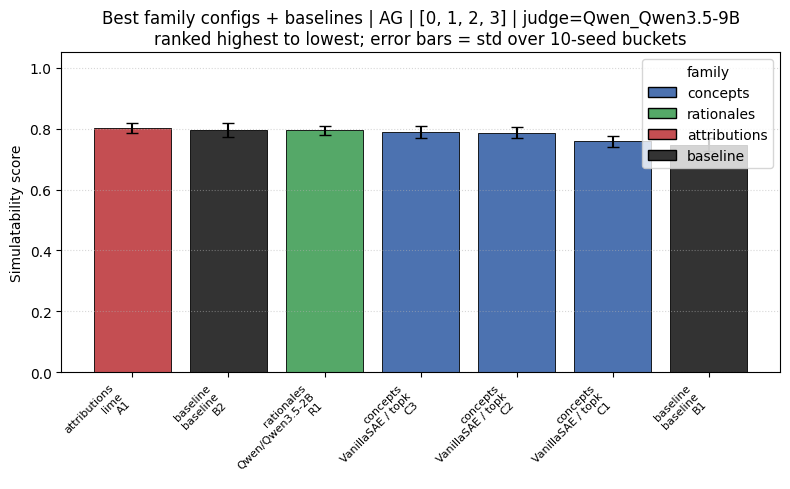

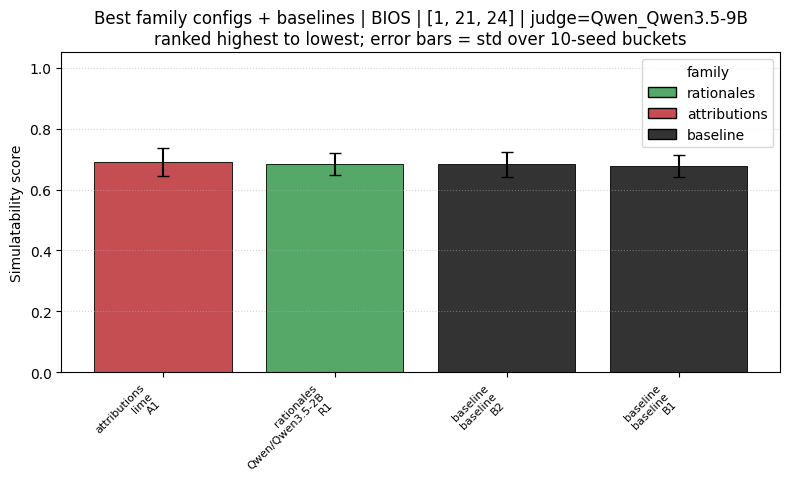

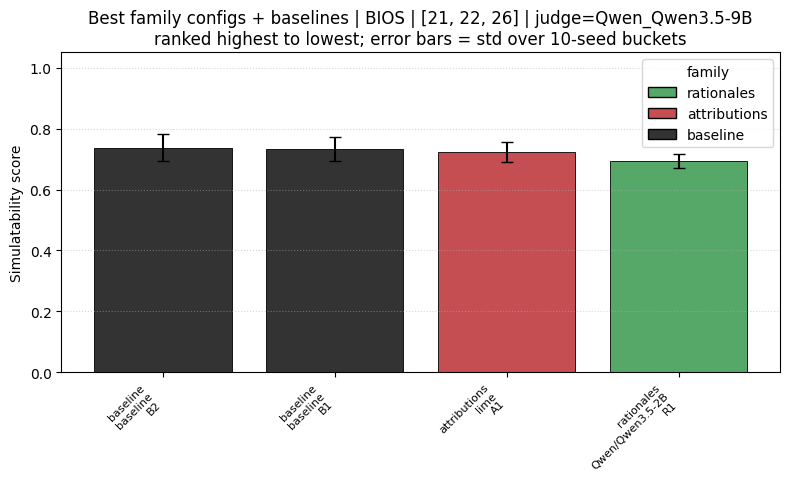

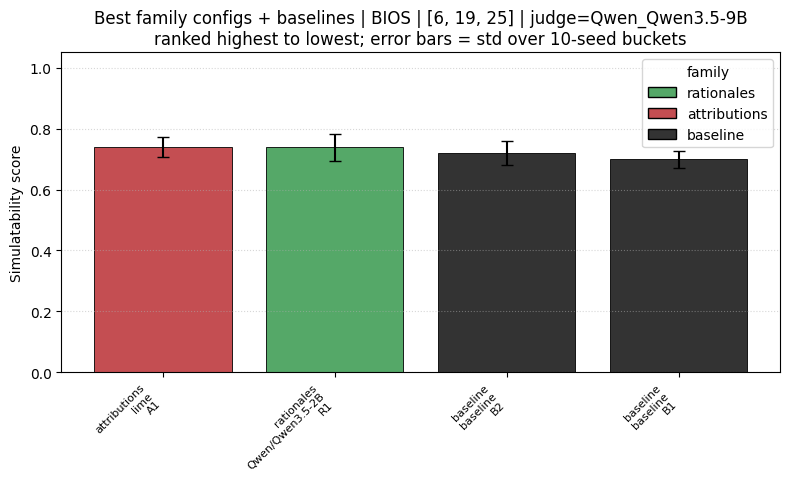

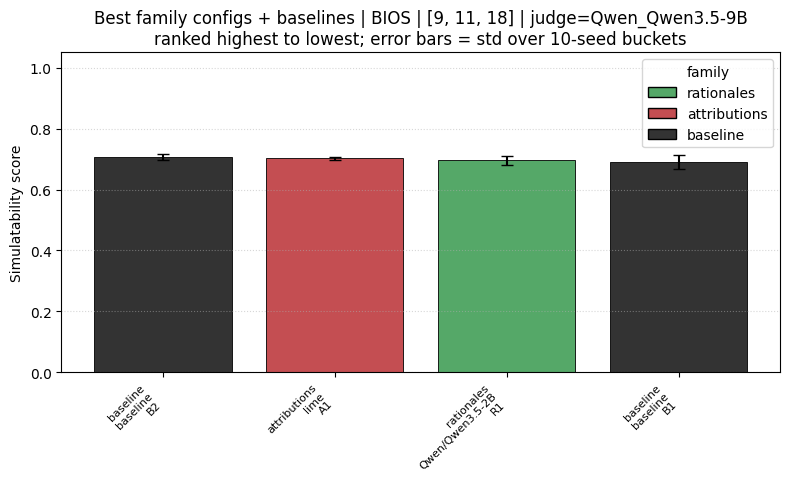

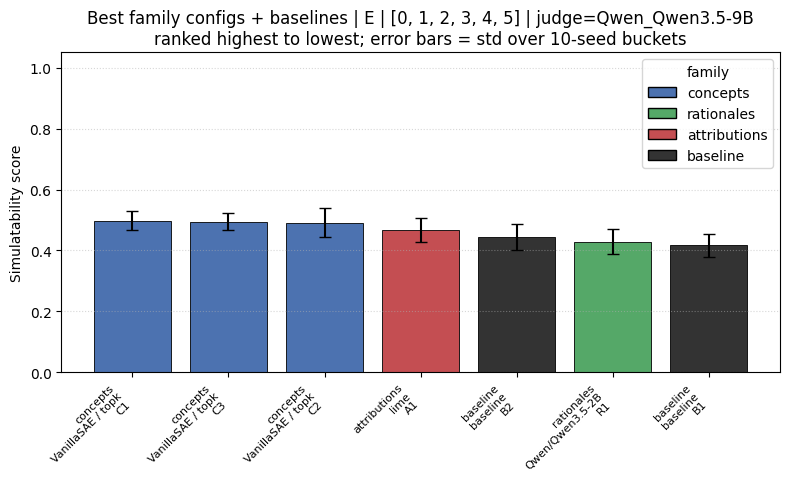

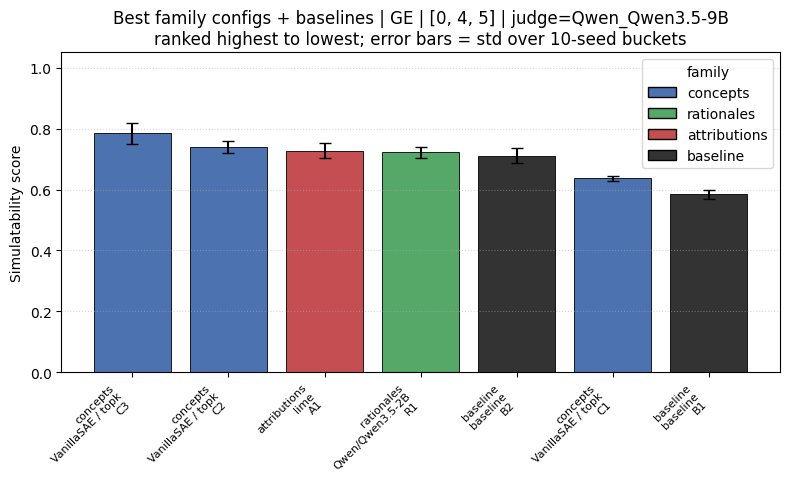

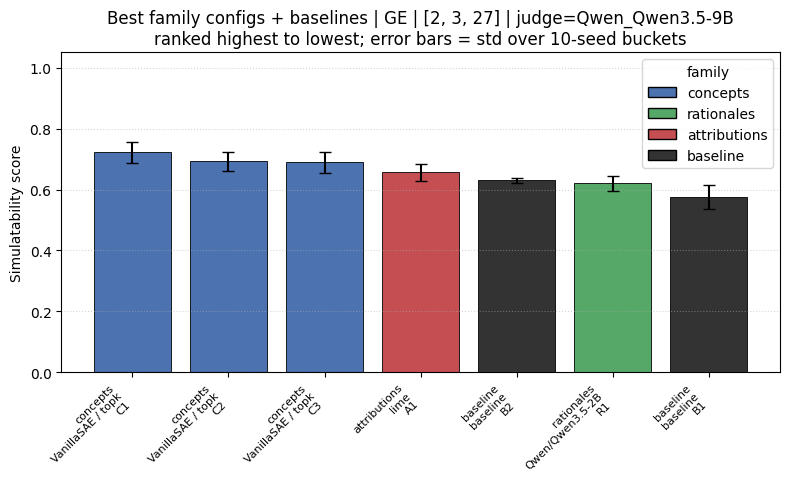

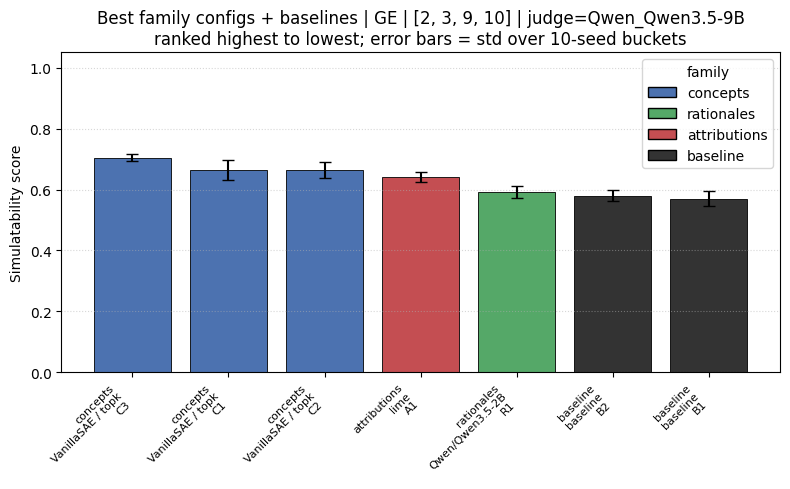

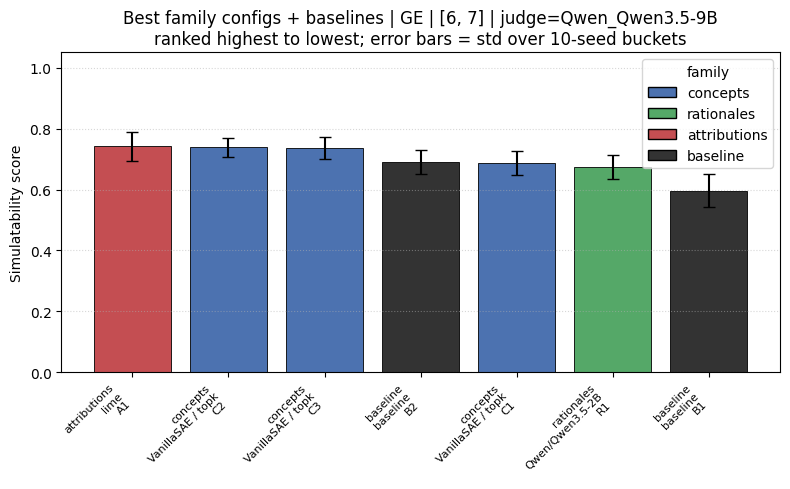

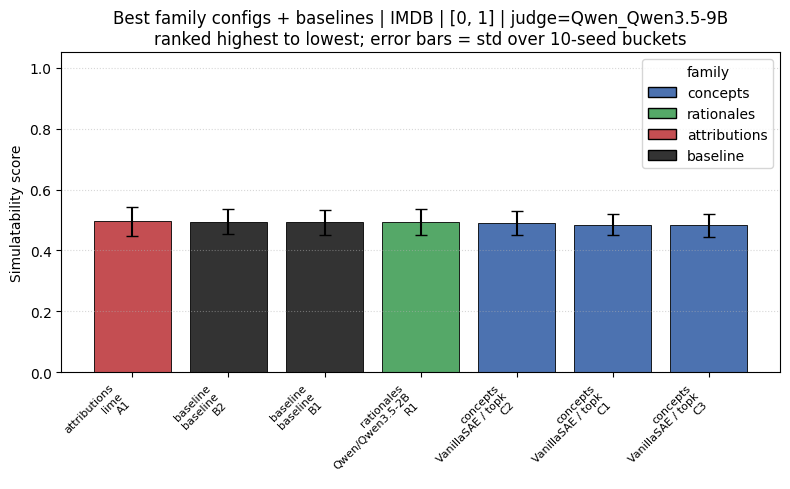

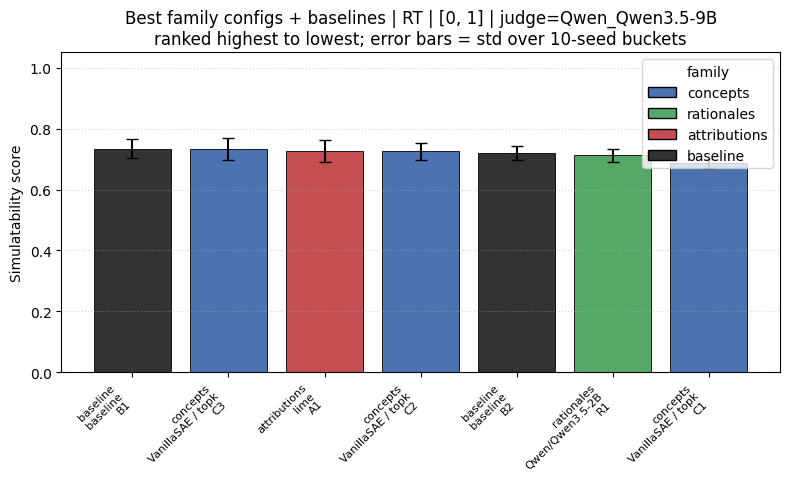

In [9]:
for panel, sub in best_plot_stats.groupby("dataset_classes_subset", dropna=False):
    safe_panel = str(panel).replace(" ", "").replace("|", "_").replace("/", "-")
    ax = plot_ranked_score_bars(
        sub,
        label_col="label",
        value_col="mean_score",
        err_col="std_score",
        color_col="family",
        color_map=FAMILY_COLORS,
        ylabel="Simulatability score",
        title=(
            f"Best family configs + baselines | {panel} | judge={MODEL_FILE}\n"
            f"ranked highest to lowest; error bars = std over {SEEDS_PER_BUCKET}-seed buckets"
        ),
        save_dir=EXPORT_DIR if EXPORT_FIGURES else None,
        file_name=f"families_best_{safe_panel}.pdf" if EXPORT_FIGURES else None,
    )
    plt.show()


## 9. Best-Prompt Allow-List for Stage 3

This allow-list is meant for the planned `scripts/make_best_prompts.py`. It records selected best methods/configurations and matching baselines, without rewriting any prompt keys.


In [10]:
def config_rows_for_allow_list(rows: pd.DataFrame, family: str) -> list[dict]:
    family_rows = rows[rows["family"] == family]
    out = []
    for _, row in family_rows.drop_duplicates(["method", "interpretation", "family_config"]).iterrows():
        entry = {"method": row["method"], "family_config": row["family_config"]}
        if family == "concepts" and not pd.isna(row.get("interpretation")):
            entry["interpretation"] = row["interpretation"]
        out.append(entry)
    return out

allow_list = {
    "concepts": config_rows_for_allow_list(best_rows, "concepts"),
    "rationales": config_rows_for_allow_list(best_rows, "rationales"),
    "attributions": config_rows_for_allow_list(best_rows, "attributions"),
    "baselines": sorted(NON_ANON_BASELINES if not INCLUDE_ANONYMIZED else (NON_ANON_BASELINES | ANON_BASELINES)),
    "source_score_file": str(CSV_PATH.relative_to(REPO_ROOT)),
    "notes": "Methods selected by notebooks/5_compare_families.ipynb; prompt keys must be preserved when copying rows to data/best_prompts/.",
}

print(json.dumps(allow_list, indent=2))

if EXPORT_ALLOW_LIST:
    out_path = BEST_PROMPTS_DIR / "allow_list.json"
    out_path.write_text(json.dumps(allow_list, indent=2) + "\n")
    print(f"Wrote {out_path.relative_to(REPO_ROOT)}")


{
  "concepts": [
    {
      "method": "VanillaSAE",
      "family_config": "VanillaSAE / topk",
      "interpretation": "topk"
    }
  ],
  "rationales": [
    {
      "method": "Qwen/Qwen3.5-2B",
      "family_config": "Qwen/Qwen3.5-2B"
    }
  ],
  "attributions": [
    {
      "method": "lime",
      "family_config": "lime"
    }
  ],
  "baselines": [
    "B1",
    "B2"
  ],
  "source_score_file": "data/consim_Qwen_Qwen3.5-9B_v2.csv",
  "notes": "Methods selected by notebooks/5_compare_families.ipynb; prompt keys must be preserved when copying rows to data/best_prompts/."
}


## 10. Paper Notes

After running the notebook, record the paper-facing takeaway here:

- Which best method/configuration was selected for each family?
- Are explanation-family scores visually separated from the baselines?
- Which plots should be included in `LaTeX-Simulatability-Shortcut/main.tex`?
- Should Stage 3 proceed with this allow-list, or should Stage 1's `simulator_consim` decision change the prompt set first?
